# PDAN8411 - Programming for Data Analytics 1
## Linear Regression: Medical Aid Cost Prediction

**Student Name:** Mpho Mubvafhi  
**Student Number:** ST10389803  
**Module Code:** PDAN8411

**Date:** 31 March 2026

**Dataset:** [Medical Cost Personal Datasets - Kaggle (Choi, 2018)](https://www.kaggle.com/datasets/mirichoi0218/insurance)  
**Objective:** Build a linear regression model that predicts individual medical aid charges based on demographic and lifestyle features, to enable a South African medical aid scheme to implement a sliding-scale cost structure.




## Table of Contents
1. [Dataset Suitability Assessment](#1-dataset-suitability-assessment)
2. [Analysis Plan](#2-analysis-plan)
3. [Library Imports](#3-library-imports)
4. [Data Loading & Initial Inspection](#4-data-loading)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
6. [Data Preprocessing & Feature Engineering](#6-data-preprocessing)
7. [Feature Selection](#7-feature-selection)
8. [Model Training](#8-model-training)
9. [Model Evaluation & Interpretation](#9-model-evaluation)
10. [Model Improvement](#10-model-improvement)
11. [Final Model Comparison](#11-final-comparison)
12. [Conclusions](#12-conclusions)




This study investigates the use of machine learning and data analytics to predict health insurance premiums using lifestyle and demographic information. Predictive models are essential for enhancing pricing and decision-making techniques due to the growing need for precise risk assessment in the insurance and healthcare sectors. This study uses linear regression modelling and exploratory data analysis on the Medical Insurance Dataset to find important variables affecting insurance premiums. The results demonstrate the usefulness of machine learning in practical financial and healthcare settings and provide insights into how factors such as age, body mass index (BMI), and smoking status affect expenses.


---
## 1. Dataset Suitability Assessment

### 1.1 Requirements for Linear Regression

Linear regression is appropriate when the following conditions are reasonably satisfied (James et al., 2021):

| Requirement | Description |
|---|---|
| **Continuous target variable** | The dependent variable must be numeric and continuous |
| **Linearity** | A linear (or approximately linear) relationship must exist between predictors and target |
| **Independence** | Observations must be independent of one another |
| **Homoscedasticity** | Variance of residuals should be approximately constant |
| **Normality of residuals** | Residuals should be approximately normally distributed |
| **No severe multicollinearity** | Predictors should not be perfectly correlated with each other |

### 1.2 Dataset Feature Overview

| Feature | Type | Role |
|---|---|---|
| `age` | Integer (continuous) | Predictor |
| `sex` | Categorical (binary) | Predictor |
| `bmi` | Float (continuous) | Predictor |
| `children` | Integer (discrete) | Predictor |
| `smoker` | Categorical (binary) | Predictor |
| `region` | Categorical (4 levels) | Predictor |
| `charges` | Float (continuous) | **Target variable** |

###  1.3 Suitability Assessment

| Criterion | Status | Rationale |
|---|---|---|
| Continuous numeric target | Pass | `charges` is float-valued USD |
| Adequate sample size | Pass | n=1338 >> 20 per predictor (Hair et al., 2019) |
| No missing values | Pass | Confirmed in documentation |
| Target skewness | Caution | `charges` is right-skewed; log-transform warranted |
| Categorical features | Caution | Require encoding before modelling |
| Multicollinearity | Verify | VIF analysis required |

**Overall verdict:** The dataset is *suitable* for linear regression with appropriate preprocessing.

**Overall verdict:** The dataset is *suitable* for linear regression with appropriate preprocessing.



## 2. Analysis Plan

The analysis follows the **CRISP-DM** methodology, adapted for this regression task.

---

### Analysis Pipeline

| Step | Phase | Description |
|------|-------|-------------|
| 1 | EDA | Exploratory Data Analysis - understand distributions, patterns, and relationships |
| 2 | Preprocessing | Handle categorical variables, scaling, and data transformations |
| 3 | Feature Selection | Identify the most relevant predictors for the model |
| 4 | Train & Evaluate | Build linear regression model and assess initial performance |
| 5 | Improve | Refine model based on evaluation metrics and diagnostics |
| 6 | Report | Document findings, insights, and model performance |

The workflow follows a sequential order from EDA through reporting, with iterative refinement between evaluation and improvement phases.



### 2a. EDA Plan

| Step | Action | Method |
|---|---|---|
| Shape & types | Dimensions and dtypes | `df.info()`, `df.describe()` |
| Missing values | Identify and handle nulls | `df.isnull().sum()` |
| Univariate analysis | Distribution of each feature | Histograms, KDE plots |
| Bivariate analysis | Relationship to `charges` | Scatter plots, box plots |
| Multivariate analysis | Inter-feature correlations | Heatmap |
| Outlier detection | Identify anomalous observations | IQR method, box plots |
| Skewness check | Assess distribution shape | `skew()`, Q-Q plots |

### 2b. Feature Selection Plan

| Method | Purpose |
|---|---|
| Pearson correlation matrix | Identify linear relationships with `charges` |
| OLS regression p-values | Backward elimination (drop features with p > 0.05) |
| Variance Inflation Factor (VIF) | Detect multicollinearity (threshold VIF > 5) |

### 2c. Model Training Plan

| Parameter | Choice | Justification |
|---|---|---|
| Algorithm | `LinearRegression` (sklearn) | Closed-form OLS solution |
| Train/Test split | 80/20 | Standard; preserves enough training data |
| Random state | 42 | Reproducibility |
| Scaling | StandardScaler | Improves coefficient interpretability |
| Cross-validation | 5-fold CV | Reduces variance in performance estimate |

### 2d. Evaluation Metrics Plan

| Metric | Interpretation |
|---|---|
| R-squared | Proportion of variance explained (higher = better) |
| Adjusted R-squared | Penalises for extra predictors |
| MAE | Average absolute error in USD |
| RMSE | Same units as target; penalises large errors heavily |
| MAPE | Percentage error; useful for business communication |
| Residual plots | Visual check of linearity, normality and homoscedasticity |

## 3. Library Imports

All required libraries are imported below. No external libraries beyond the standard data science stack are required.

In [1]:

import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold'})

# Statistical analysis
from scipy import stats

# Scikit-Learn preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Scikit-Learn models
from sklearn.linear_model import LinearRegression, RidgeCV

# Scikit-Learn evaluation
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)

# Reproducibility seed
SEED = 42
np.random.seed(SEED)

print('All libraries imported successfully.')


All libraries imported successfully.


## 4. Data Loading & Initial Inspection

The dataset is loaded from a local CSV file (downloaded from Kaggle). Initial checks cover shape, data types, descriptive statistics, missing values, and duplicates.

In [2]:

# Dataset source:
# Choi, M. (2018). Medical Cost Personal Datasets. Kaggle.
# https://www.kaggle.com/datasets/mirichoi0218/insurance
# Download insurance.csv and place it in the same directory as this notebook.

df = pd.read_csv('insurance.csv')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
print('\nFirst five records:')
df.head()


Dataset shape: 1338 rows x 7 columns

First five records:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### DataFrame Structure

| Column | Non-Null Count | Data Type |
|--------|----------------|-----------|
| age | 1338 | int64 |
| sex | 1338 | object |
| bmi | 1338 | float64 |
| children | 1338 | int64 |
| smoker | 1338 | object |
| region | 1338 | object |
| charges | 1338 | float64 |

**Observations:**
- Total records: 1338
- No missing values in any column
- Mixed data types: 2 numerical integers, 2 numerical floats, 3 categorical objects

In [3]:

# Data types and non-null counts
# This confirms the dtype of each column and whether all rows are populated.
print(' DataFrame Info ')
df.info()

 DataFrame Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# Statistical summary for categorical features
print(' Descriptive Statistics (Categorical) ')

# Get categorical summary
cat_summary = df.describe(include='object')

# Display with proper formatting
print(cat_summary.to_string())

 Descriptive Statistics (Categorical) 
         sex smoker     region
count   1338   1338       1338
unique     2      2          4
top     male     no  southeast
freq     676   1064        364


In [5]:
# Missing value audit - critical step before any modelling
missing = df.isnull().sum()
pct_missing = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': pct_missing})
print(' Missing Value Report ')
print(missing_report)
print(f'\nTotal missing values: {missing.sum()}')

 Missing Value Report 
          Missing Count  Missing %
age                   0        0.0
sex                   0        0.0
bmi                   0        0.0
children              0        0.0
smoker                0        0.0
region                0        0.0
charges               0        0.0

Total missing values: 0


In [6]:

# Duplicate record check - duplicate rows can bias model training
duplicates = df.duplicated().sum()
print(f'Duplicate rows detected: {duplicates}')
if duplicates > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found. Dataset integrity confirmed.')

Duplicate rows detected: 1
Duplicates removed. New shape: (1337, 7)


In [7]:
# =============== CODE CELL ===============
# Value counts for categorical variables
# Checks class balance and confirms expected category levels
for col in ['sex', 'smoker', 'region']:
    print(f'\n {col.upper()} ')
    print(df[col].value_counts())
    print(f'  Unique values: {df[col].nunique()}')


 SEX 
sex
male      675
female    662
Name: count, dtype: int64
  Unique values: 2

 SMOKER 
smoker
no     1063
yes     274
Name: count, dtype: int64
  Unique values: 2

 REGION 
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
  Unique values: 4


## 5. Exploratory Data Analysis

The dataset's exploratory data analysis identified a number of significant trends. The distribution of insurance prices is positively skewed, meaning that although most people pay reasonable amounts, a smaller minority pays much more. The most significant factor was found to be smoking status; smokers were continuously linked to significantly greater charges than non-smokers. Furthermore, there is a significant correlation between insurance costs and age, indicating that older people typically have higher medical bills. Increased fees are also influenced by body mass index (BMI), especially for those who are overweight or obese. These trends demonstrate how crucial lifestyle and demographic variables are in influencing insurance risk and cost.

EDA is conducted in the following order:
- **5.1** Univariate analysis - distribution of each variable
- **5.2** Target variable analysis and log transformation
- **5.3** Bivariate analysis - predictors vs charges
- **5.4** Critical interaction: BMI x Smoker
- **5.5** Correlation heatmap
- **5.6** Outlier detection (IQR method)
- **5.7** Age-group segmentation

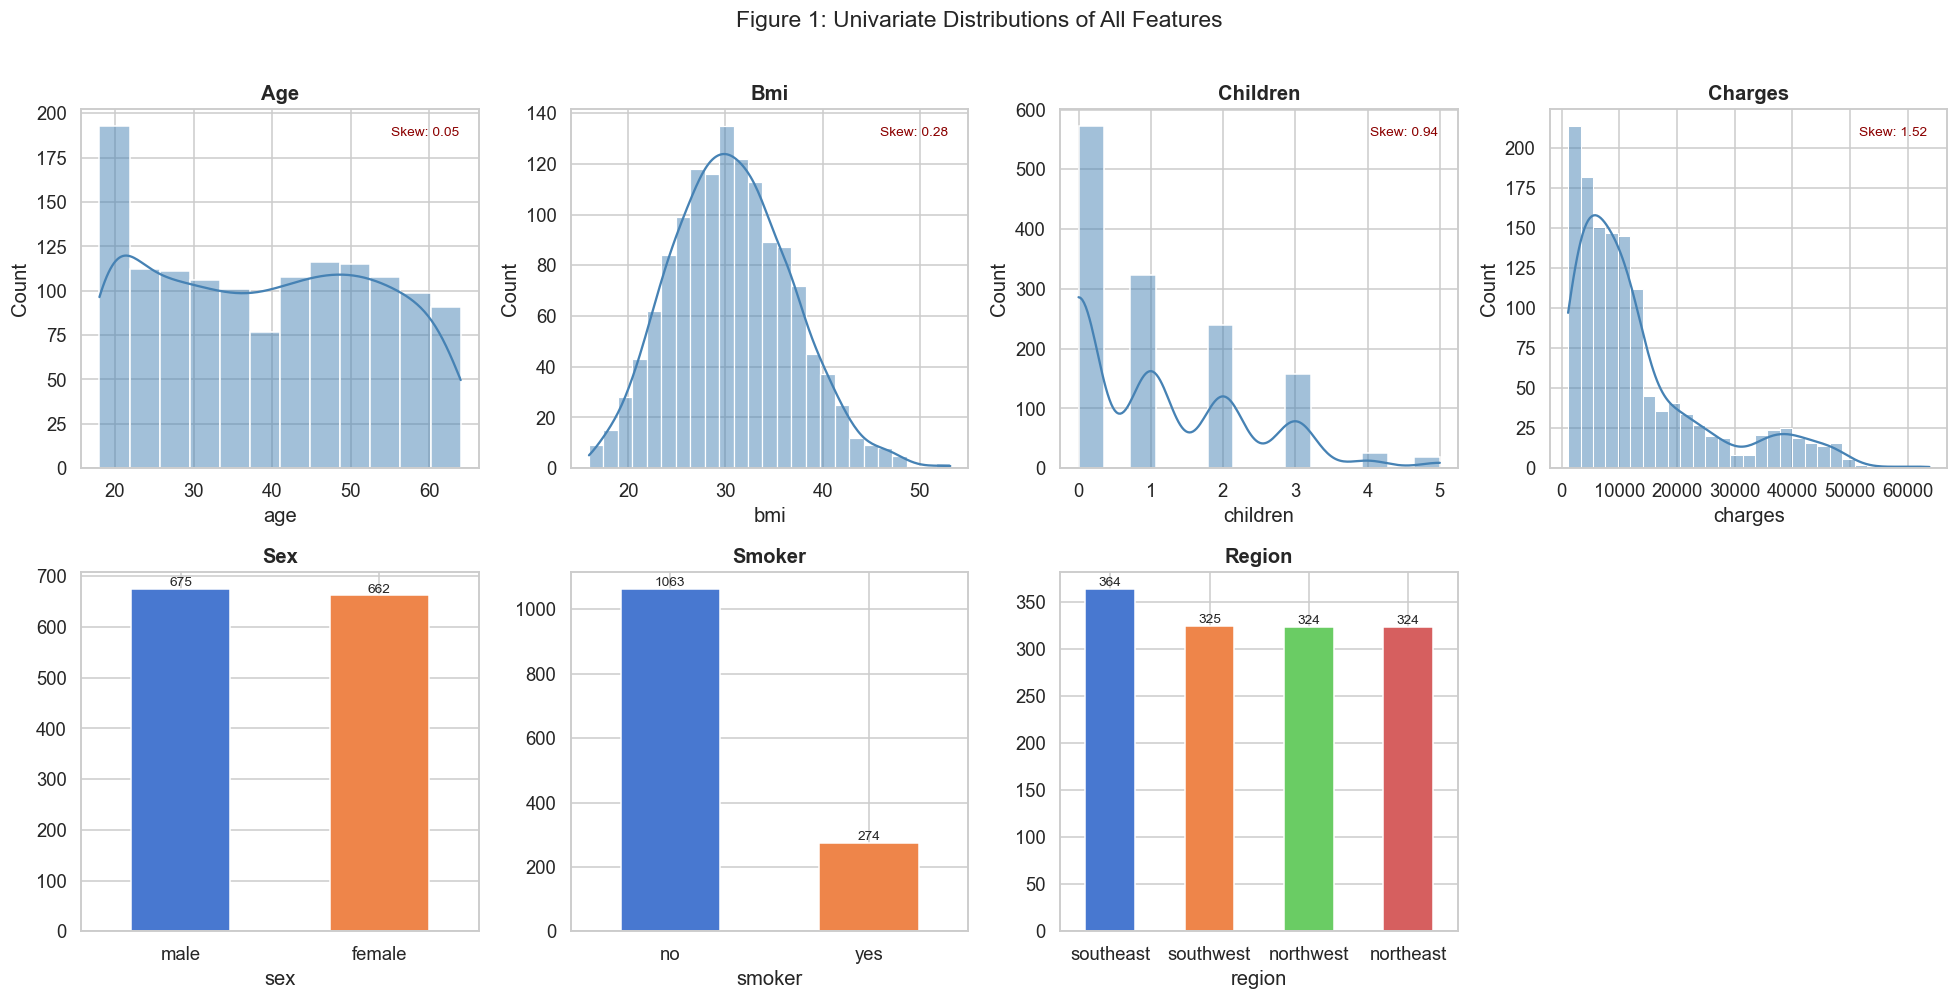

Key observation: charges exhibits strong positive (right) skew of 1.51.


In [8]:
# 5.1 Univariate Analysis
# Histograms with KDE for numeric features; bar charts for categorical features.
# Skewness is annotated on each numeric plot.

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Figure 1: Univariate Distributions of All Features', fontsize=15, y=1.01)

numeric_cols = ['age', 'bmi', 'children', 'charges']
categorical_cols = ['sex', 'smoker', 'region']

# Numeric histograms with KDE overlay
for i, col in enumerate(numeric_cols):
    ax = axes[0, i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col.capitalize())
    skewness = df[col].skew()
    ax.text(0.95, 0.95, f'Skew: {skewness:.2f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='darkred')

# Categorical bar charts with count labels
for i, col in enumerate(categorical_cols):
    ax = axes[1, i]
    vc = df[col].value_counts()
    vc.plot(kind='bar', ax=ax, color=sns.color_palette('muted'), edgecolor='white', rot=0)
    ax.set_title(col.capitalize())
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)

axes[1, 3].axis('off')  # Hide unused subplot
plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers
print('Key observation: charges exhibits strong positive (right) skew of 1.51.')


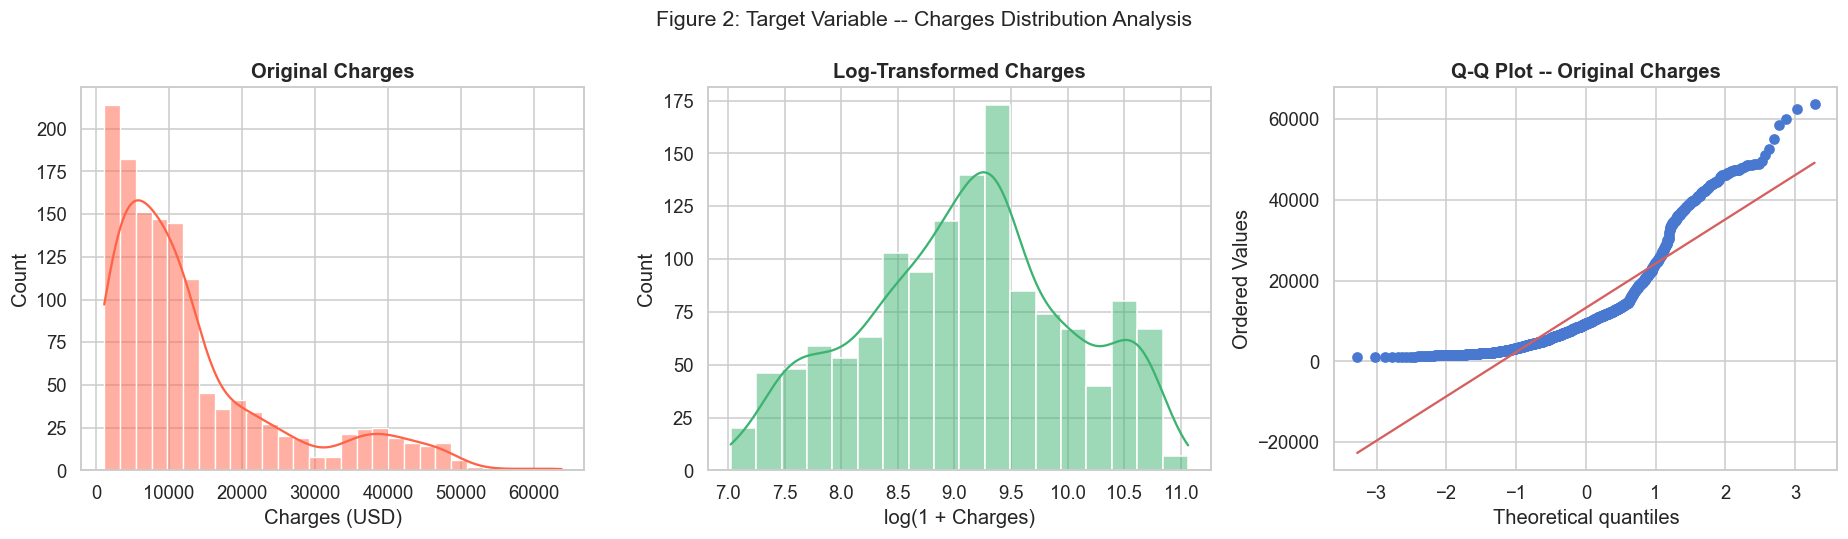

Original charges skewness    : 1.5154
Log-transformed skewness     : -0.0896
Log transformation significantly reduces skewness -- will be used in improved model.


In [9]:
# 5.2 Target Variable: Skewness and Log Transformation
# Three plots: original distribution, log-transformed distribution, Q-Q plot.
# log1p = log(1 + x) to safely handle any zero values.

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Figure 2: Target Variable -- Charges Distribution Analysis', fontsize=14)

sns.histplot(df['charges'], kde=True, ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Original Charges')
axes[0].set_xlabel('Charges (USD)')

log_charges = np.log1p(df['charges'])
sns.histplot(log_charges, kde=True, ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Log-Transformed Charges')
axes[1].set_xlabel('log(1 + Charges)')

stats.probplot(df['charges'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot -- Original Charges')

plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers

print(f'Original charges skewness    : {df["charges"].skew():.4f}')
print(f'Log-transformed skewness     : {log_charges.skew():.4f}')
print('Log transformation significantly reduces skewness -- will be used in improved model.')


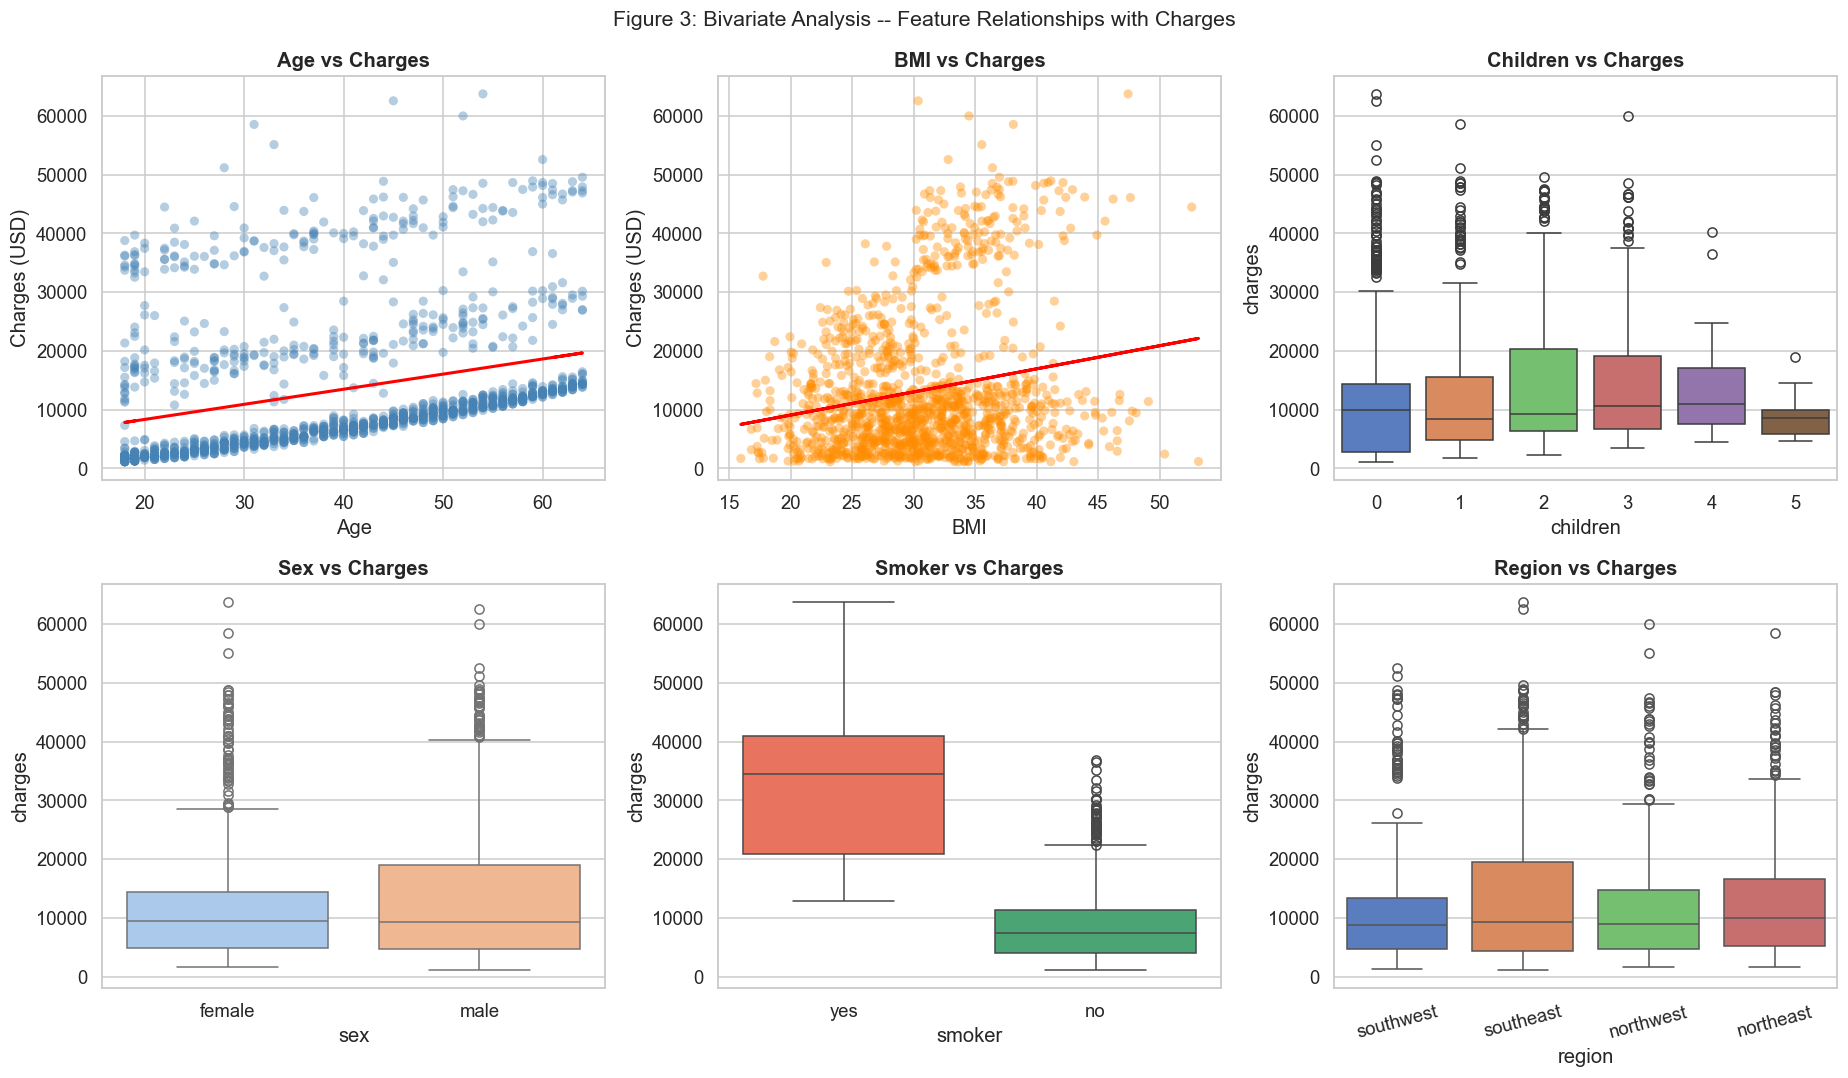

Key finding: Smokers pay dramatically higher charges  the single strongest predictor.
Sex and region show negligible effects on charges.


In [10]:
# 5.3 Bivariate Analysis: Each Predictor vs Charges
# Numeric predictors: scatter plots with trend lines
# Categorical predictors: box plots to show distribution differences

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Figure 3: Bivariate Analysis -- Feature Relationships with Charges', fontsize=14)

# Age vs Charges -- positive linear trend expected
axes[0, 0].scatter(df['age'], df['charges'], alpha=0.4, color='steelblue', edgecolors='none')
axes[0, 0].set_xlabel('Age'); axes[0, 0].set_ylabel('Charges (USD)')
axes[0, 0].set_title('Age vs Charges')
m, b = np.polyfit(df['age'], df['charges'], 1)
axes[0, 0].plot(df['age'], m * df['age'] + b, color='red', linewidth=2)

# BMI vs Charges
axes[0, 1].scatter(df['bmi'], df['charges'], alpha=0.4, color='darkorange', edgecolors='none')
axes[0, 1].set_xlabel('BMI'); axes[0, 1].set_ylabel('Charges (USD)')
axes[0, 1].set_title('BMI vs Charges')
m, b = np.polyfit(df['bmi'], df['charges'], 1)
axes[0, 1].plot(df['bmi'], m * df['bmi'] + b, color='red', linewidth=2)

# Children vs Charges -- box plot to show spread per group
sns.boxplot(x='children', y='charges', data=df, ax=axes[0, 2], palette='muted')
axes[0, 2].set_title('Children vs Charges')

# Sex vs Charges
sns.boxplot(x='sex', y='charges', data=df, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Sex vs Charges')

# Smoker vs Charges -- the most striking relationship
sns.boxplot(x='smoker', y='charges', data=df, ax=axes[1, 1],
            palette={'yes': 'tomato', 'no': 'mediumseagreen'})
axes[1, 1].set_title('Smoker vs Charges')

# Region vs Charges
sns.boxplot(x='region', y='charges', data=df, ax=axes[1, 2], palette='muted')
axes[1, 2].set_title('Region vs Charges')
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers

print('Key finding: Smokers pay dramatically higher charges  the single strongest predictor.')
print('Sex and region show negligible effects on charges.')


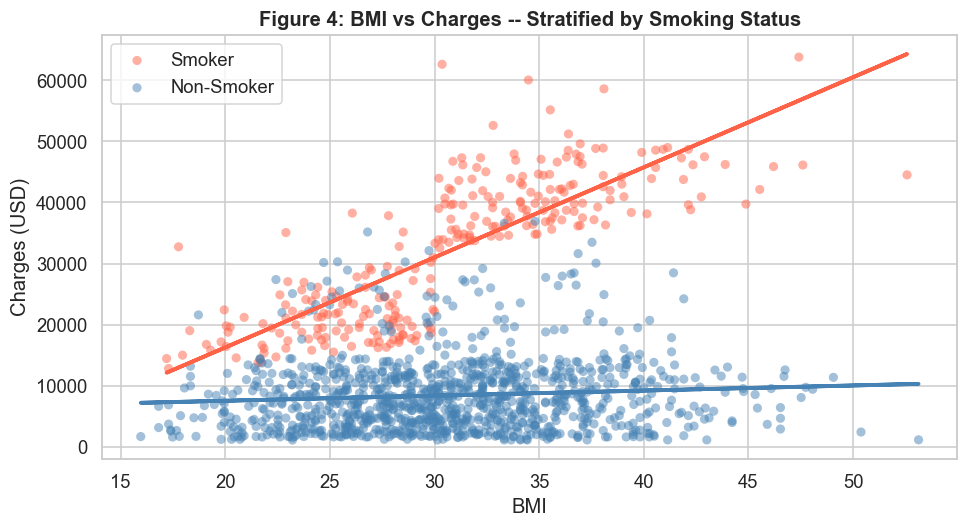

CRITICAL INSIGHT: For smokers, a steep positive BMI-charges slope exists.
For non-smokers, the slope is near-flat.
=> bmi_smoker interaction term will be engineered in preprocessing.


In [11]:
# 5.4 Critical Interaction: BMI x Smoker
# Stratifying the BMI-charges scatter by smoking status reveals a dramatically
# different slope for smokers vs non-smokers. This is a key feature engineering insight.

fig, ax = plt.subplots(figsize=(9, 5))
for smoker_status, color, label in [('yes', 'tomato', 'Smoker'),
                                      ('no', 'steelblue', 'Non-Smoker')]:
    subset = df[df['smoker'] == smoker_status]
    ax.scatter(subset['bmi'], subset['charges'], alpha=0.5, color=color,
               label=label, edgecolors='none')
    m, b = np.polyfit(subset['bmi'], subset['charges'], 1)
    ax.plot(subset['bmi'], m * subset['bmi'] + b, color=color, linewidth=2.5)

ax.set_xlabel('BMI'); ax.set_ylabel('Charges (USD)')
ax.set_title('Figure 4: BMI vs Charges -- Stratified by Smoking Status')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers

print('CRITICAL INSIGHT: For smokers, a steep positive BMI-charges slope exists.')
print('For non-smokers, the slope is near-flat.')
print('=> bmi_smoker interaction term will be engineered in preprocessing.')


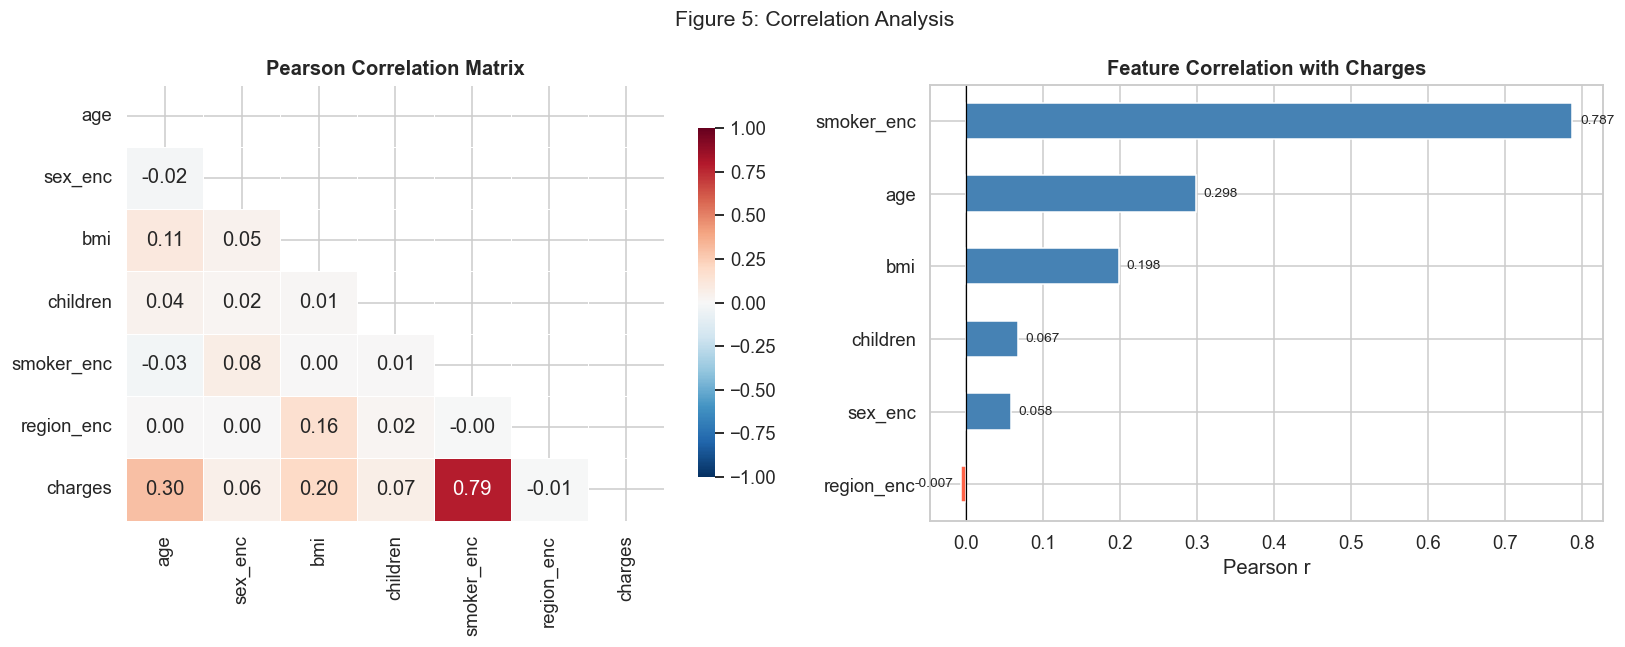

Correlation with charges (ranked):
smoker_enc    0.787234
age           0.298308
bmi           0.198401
children      0.067389
sex_enc       0.058044
region_enc   -0.006547


In [12]:
# 5.5 Correlation Analysis
# Categorical variables are label-encoded for correlation purposes only (not for modelling).
# Two plots: full heatmap + ranked bar chart of correlations with target.

df_encoded_temp = df.copy()
df_encoded_temp['sex_enc']    = (df['sex']    == 'male').astype(int)
df_encoded_temp['smoker_enc'] = (df['smoker'] == 'yes').astype(int)
df_encoded_temp['region_enc'] = df['region'].map({'northeast': 0, 'northwest': 1,
                                                    'southeast': 2, 'southwest': 3})

corr_cols = ['age', 'sex_enc', 'bmi', 'children', 'smoker_enc', 'region_enc', 'charges']
corr_matrix = df_encoded_temp[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 5: Correlation Analysis', fontsize=14)

# Lower-triangle heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson Correlation Matrix')

# Ranked bar chart: correlation with target only
target_corr = corr_matrix['charges'].drop('charges').sort_values(ascending=True)
colors = ['tomato' if c < 0 else 'steelblue' for c in target_corr]
target_corr.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Correlation with Charges')
axes[1].set_xlabel('Pearson r')

for i, val in enumerate(target_corr):
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i,
                 f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers

print('Correlation with charges (ranked):')
print(target_corr.sort_values(ascending=False).to_string())


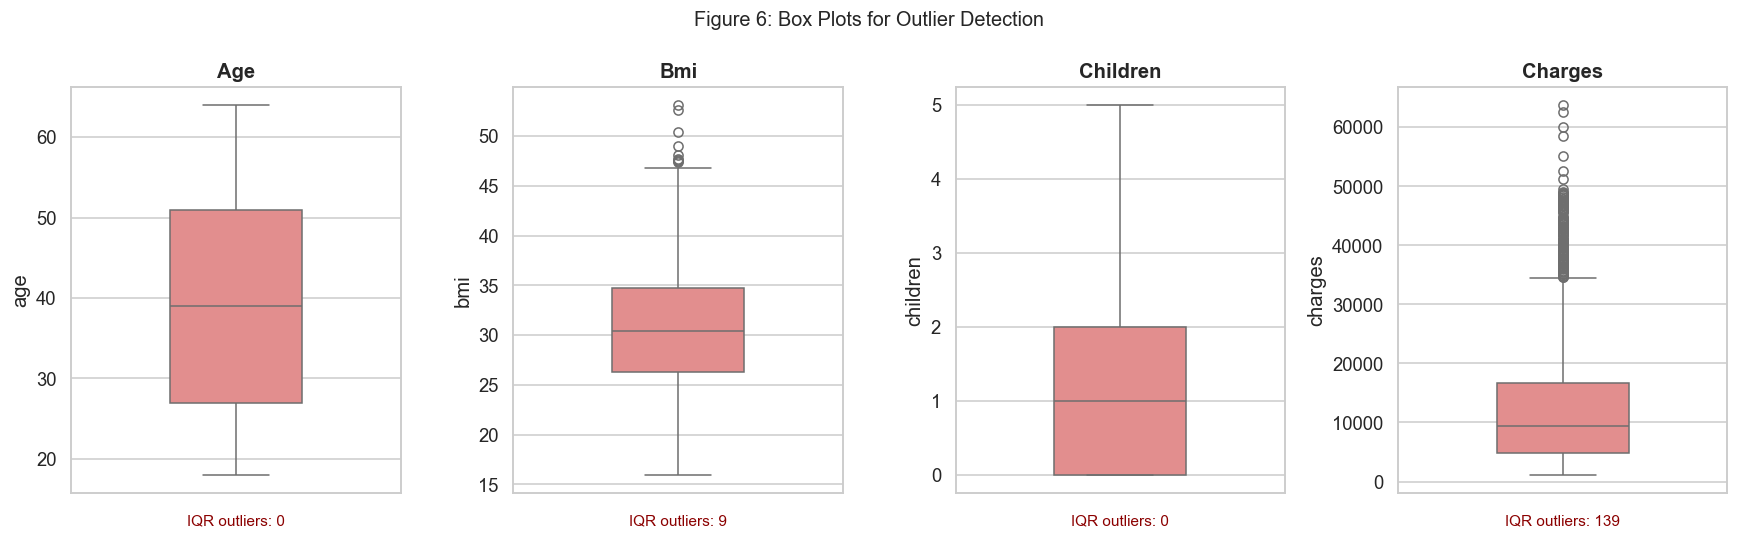

 Outlier Summary (IQR 1.5x fence) 
  age         :   0 outliers  (fence: [-9.0, 87.0])
  bmi         :   9 outliers  (fence: [13.7, 47.3])
  children    :   0 outliers  (fence: [-3.0, 5.0])
  charges     : 139 outliers  (fence: [-13120.7, 34524.8])

Decision: Outliers retained  represent genuine high-risk patients.
Log transformation of charges will mitigate their influence.


In [13]:
# 5.6 Outlier Detection -- IQR Method (1.5x fence)
# Box plots show outliers visually; IQR report quantifies them.
# Decision: retain all outliers as they represent real high-risk patients.

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Figure 6: Box Plots for Outlier Detection', fontsize=13)

for ax, col in zip(axes, ['age', 'bmi', 'children', 'charges']):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral', width=0.4)
    Q1 = df[col].quantile(0.25); Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    ax.set_title(col.capitalize())
    ax.set_xlabel(f'IQR outliers: {n_outliers}', fontsize=10, color='darkred')

plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers

# Detailed report
print(' Outlier Summary (IQR 1.5x fence) ')
for col in ['age', 'bmi', 'children', 'charges']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f'  {col:12s}: {n_out:3d} outliers  (fence: [{Q1-1.5*IQR:.1f}, {Q3+1.5*IQR:.1f}])')

print('\nDecision: Outliers retained  represent genuine high-risk patients.')
print('Log transformation of charges will mitigate their influence.')


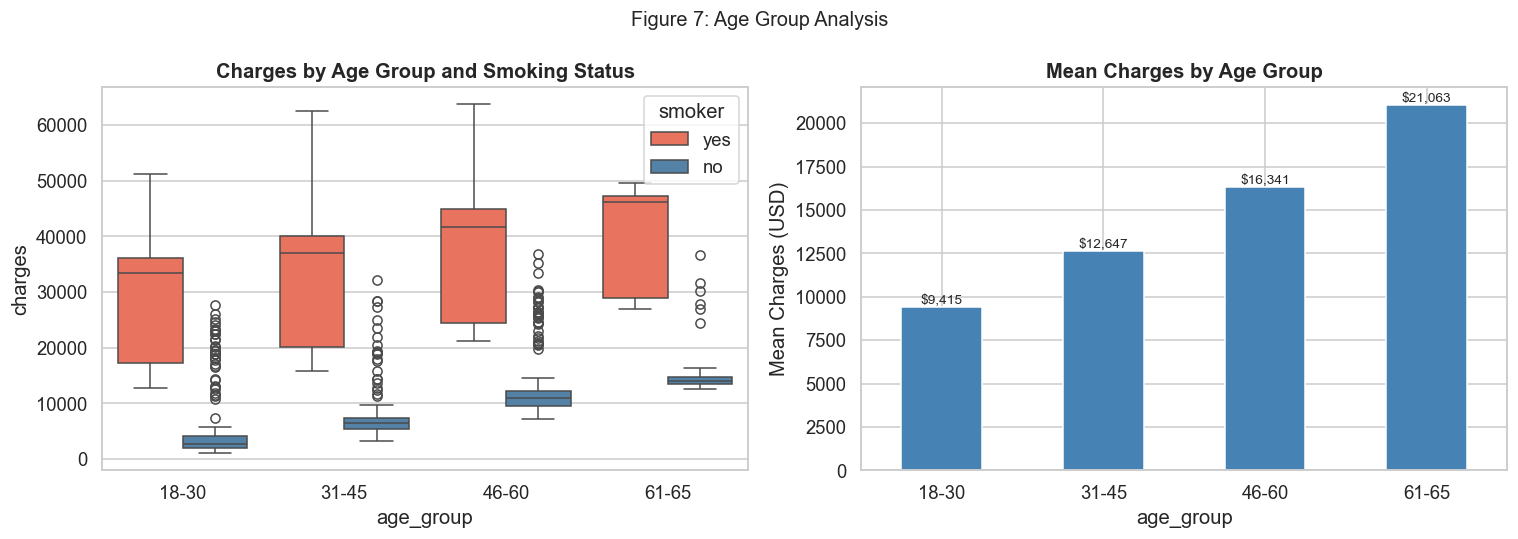

Charges increase consistently with age. Smoker premium grows with age.


In [14]:
# 5.7 Age-Group Segmentation Analysis
# Segmenting by age group and smoking status reveals how both factors compound.

df_plot = df.copy()
df_plot['age_group'] = pd.cut(df['age'], bins=[17, 30, 45, 60, 65],
                               labels=['18-30', '31-45', '46-60', '61-65'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 7: Age Group Analysis', fontsize=13)

sns.boxplot(x='age_group', y='charges', hue='smoker', data=df_plot,
            ax=axes[0], palette={'yes': 'tomato', 'no': 'steelblue'})
axes[0].set_title('Charges by Age Group and Smoking Status')

avg_charges = df_plot.groupby('age_group', observed=True)['charges'].mean()
avg_charges.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white', rot=0)
axes[1].set_title('Mean Charges by Age Group')
axes[1].set_ylabel('Mean Charges (USD)')
for p in axes[1].patches:
    axes[1].annotate(f'${p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers
print('Charges increase consistently with age. Smoker premium grows with age.')


## 6. Data Preprocessing & Feature Engineering

Based on EDA findings, the following steps are applied before model training:

| Step | Method | Reason |
|---|---|---|
| Binary encode `sex` & `smoker` | LabelEncoder | Two levels each; ordinal encoding suitable |
| One-Hot Encode `region` | `pd.get_dummies(drop_first=True)` | 4 nominal levels; avoid dummy trap |
| Create `bmi_smoker` feature | `bmi x smoker_encoded` | Captures BMI penalty for smokers (EDA insight) |
| Create `age_smoker` feature | `age x smoker_encoded` | Captures compounding age+smoking risk |
| StandardScaler | Fit on train only | Zero-mean unit-variance; prevents data leakage |


In [15]:
# 6.1 Encoding categorical variables
df_model = df.copy()

# Binary encoding: LabelEncoder maps each unique value to 0 or 1
df_model['sex']    = LabelEncoder().fit_transform(df_model['sex'])    # female=0, male=1
df_model['smoker'] = LabelEncoder().fit_transform(df_model['smoker']) # no=0, yes=1

# One-Hot Encoding for region
# drop_first=True removes one dummy column (northeast) to avoid multicollinearity
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True, dtype=int)

print(' Encoding Summary \n')

# Create encoding summary table
encoding_summary = pd.DataFrame({
    'Variable': ['sex', 'smoker', 'region'],
    'Original Categories': ['female, male', 'no, yes', 'northeast, northwest, southeast, southwest'],
    'Encoding Method': ['LabelEncoder', 'LabelEncoder', 'One-Hot Encoding (drop_first=True)'],
    'Encoded Values': ['0=female, 1=male', '0=no, 1=yes', '3 dummy variables: region_northwest, region_southeast, region_southwest']
})

print(encoding_summary.to_string(index=False))
print(f'\n{"="*60}')
print(f'Encoded DataFrame Shape: {df_model.shape}')
print(f'Original DataFrame Shape: {df.shape}')
print(f'New columns added: {df_model.shape[1] - df.shape[1]} (dummy variables)')
print(f'{"="*60}\n')

print('Encoded DataFrame -- First 5 Rows:')
print(df_model.head())

 Encoding Summary 

Variable                        Original Categories                    Encoding Method                                                          Encoded Values
     sex                               female, male                       LabelEncoder                                                        0=female, 1=male
  smoker                                    no, yes                       LabelEncoder                                                             0=no, 1=yes
  region northeast, northwest, southeast, southwest One-Hot Encoding (drop_first=True) 3 dummy variables: region_northwest, region_southeast, region_southwest

Encoded DataFrame Shape: (1337, 9)
Original DataFrame Shape: (1337, 7)
New columns added: 2 (dummy variables)

Encoded DataFrame -- First 5 Rows:
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230   

In [16]:
# 6.2 Feature Engineering -- Interaction Terms
# Rationale: EDA (Figure 4) revealed a stark difference in the BMI-charges
# relationship between smokers and non-smokers. An interaction term (bmi * smoker)
# explicitly models this synergistic effect.

df_model['bmi_smoker'] = df_model['bmi'] * df_model['smoker']
df_model['age_smoker'] = df_model['age'] * df_model['smoker']

print('Interaction features added:')
print('  bmi_smoker = bmi x smoker  (BMI penalty amplified for smokers)')
print('  age_smoker = age x smoker  (Age penalty amplified for smokers)')
print(f'\nFinal feature columns: {list(df_model.columns)}')

Interaction features added:
  bmi_smoker = bmi x smoker  (BMI penalty amplified for smokers)
  age_smoker = age x smoker  (Age penalty amplified for smokers)

Final feature columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker', 'age_smoker']


## 7. Feature Selection

Two complementary methods are used:

1. **Variance Inflation Factor (VIF)** - checks for multicollinearity among predictors
2. **Backward Elimination via OLS p-values** - removes statistically insignificant predictors

> **Code attribution:** The OLS normal equation structure in `ols_pvalues()` below was adapted from Geron, A. (2022). *Hands-On Machine Learning*. O'Reilly, p. 118.

 VIF Results 
         Feature    VIF
          smoker 31.078
      bmi_smoker 25.667
      age_smoker  8.982
region_southeast  1.654
region_southwest  1.531
region_northwest  1.519
             bmi  1.393
             age  1.277
             sex  1.012
        children  1.005


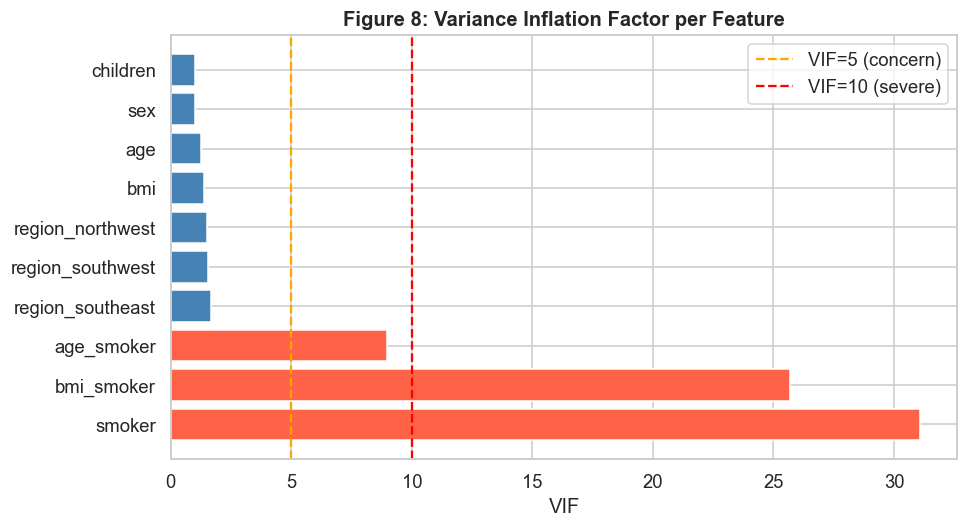

In [17]:
# 7.1 Variance Inflation Factor (VIF)
# VIF > 5: concern; VIF > 10: severe multicollinearity (Hair et al., 2019)
# Custom implementation using sklearn R^2 -- replicates statsmodels VIF

def calculate_vif(X_df):
    """Compute VIF for each feature in X_df."""
    results = []
    for col in X_df.columns:
        y_col = X_df[col].values
        X_others = X_df.drop(columns=[col]).values
        r2 = LinearRegression().fit(X_others, y_col).score(X_others, y_col)
        vif = 1 / (1 - r2) if r2 < 1 else float('inf')
        results.append({'Feature': col, 'VIF': round(vif, 3)})
    return pd.DataFrame(results).sort_values('VIF', ascending=False)

feature_cols = [c for c in df_model.columns if c != 'charges']
X_all = df_model[feature_cols].copy()
vif_df = calculate_vif(X_all)

print(' VIF Results ')
print(vif_df.to_string(index=False))

# Visual VIF plot
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if v > 5 else 'steelblue' for v in vif_df['VIF']]
ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors, edgecolor='white')
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='VIF=5 (concern)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='VIF=10 (severe)')
ax.set_title('Figure 8: Variance Inflation Factor per Feature')
ax.set_xlabel('VIF')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers


In [18]:
# 7.2 Backward Elimination via OLS p-values
# Iteratively removes the predictor with the highest p-value (if p > 0.05)

def ols_pvalues(X_df, y_arr):
    """Compute OLS coefficients, standard errors, t-stats and two-tailed p-values."""
    X_b = np.c_[np.ones(X_df.shape[0]), X_df.values]
    beta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y_arr
    residuals = y_arr - X_b @ beta
    n, k = X_b.shape
    sigma2 = (residuals @ residuals) / (n - k)
    cov_beta = sigma2 * np.linalg.pinv(X_b.T @ X_b)
    se = np.sqrt(np.diag(cov_beta))
    t_stats = beta / se
    p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))
    names = ['Intercept'] + list(X_df.columns)
    return pd.DataFrame({'Feature': names, 'Coef': beta.round(2),
                         'Std_Err': se.round(2), 't_stat': t_stats.round(3),
                         'p_value': p_vals.round(6)})

def backward_elimination(X_df, y_arr, alpha=0.05):
    """Iteratively remove the feature with the highest p-value above alpha."""
    current_X = X_df.copy()
    dropped = []
    itr = 0
    while True:
        result = ols_pvalues(current_X, y_arr)
        non_intercept = result[result['Feature'] != 'Intercept']
        max_p = non_intercept['p_value'].max()
        if max_p > alpha:
            worst = non_intercept.loc[non_intercept['p_value'].idxmax(), 'Feature']
            print(f'  Iteration {itr+1}: Dropping "{worst}" (p = {max_p:.4f})')
            current_X = current_X.drop(columns=[worst])
            dropped.append(worst)
            itr += 1
        else:
            break
    print(f'\nBackward elimination complete. Features dropped: {dropped}')
    return current_X

y = df_model['charges'].values
print(' Backward Elimination (significance level: alpha = 0.05) ')
X_selected = backward_elimination(X_all, y)

# Create final results table
final_results = ols_pvalues(X_selected, y)

print('\n' + '='*70)
print('FINAL OLS SUMMARY TABLE')
print('='*70)
print(final_results.to_string(index=False))

# Create feature selection summary table
all_features = list(X_all.columns)
retained_features = list(X_selected.columns)
dropped_features = [f for f in all_features if f not in retained_features]

print('\n' + '='*70)
print('FEATURE SELECTION SUMMARY')
print('='*70)

selection_summary = pd.DataFrame({
    'Feature': all_features,
    'Status': ['Retained' if f in retained_features else 'Dropped' for f in all_features],
    'Reason': ['p < 0.05 (significant)' if f in retained_features else 'p > 0.05 (insignificant)' for f in all_features]
})
print(selection_summary.to_string(index=False))

print(f'\nTotal features: {len(all_features)}')
print(f'Features retained: {len(retained_features)}')
print(f'Features dropped: {len(dropped_features)}')
print(f'Final selected features: {retained_features}')


 Backward Elimination (significance level: alpha = 0.05) 
  Iteration 1: Dropping "age_smoker" (p = 0.9229)
  Iteration 2: Dropping "bmi" (p = 0.3575)
  Iteration 3: Dropping "region_northwest" (p = 0.1243)
  Iteration 4: Dropping "sex" (p = 0.0656)

Backward elimination complete. Features dropped: ['age_smoker', 'bmi', 'region_northwest', 'sex']

FINAL OLS SUMMARY TABLE
         Feature      Coef  Std_Err  t_stat  p_value
       Intercept  -2109.71   437.43  -4.823 0.000002
             age    264.98     9.47  27.972 0.000000
        children    508.74   110.31   4.612 0.000004
          smoker -20901.64  1477.83 -14.143 0.000000
region_southeast   -842.57   321.81  -2.618 0.008939
region_southwest   -914.42   330.63  -2.766 0.005759
      bmi_smoker   1457.68    46.99  31.022 0.000000

FEATURE SELECTION SUMMARY
         Feature   Status                   Reason
             age Retained   p < 0.05 (significant)
             sex  Dropped p > 0.05 (insignificant)
             bmi  Drop

### 8. Model Training - Baseline Linear Regression

The model is trained following these steps:
1. Prepare feature matrix and target vector from selected features
2. 80/20 train/test split (random_state=42 for reproducibility)
3. StandardScaler (fit on training set only - prevents data leakage)
4. Train `LinearRegression` model
5. 5-fold cross-validation to assess generalisation

In [19]:
# 8.1 Prepare feature matrix and target vector
selected_features = list(X_selected.columns)
X = df_model[selected_features].copy()
y = df_model['charges'].copy()

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Selected features    : {selected_features}')


Feature matrix shape : (1337, 6)
Target vector shape  : (1337,)
Selected features    : ['age', 'children', 'smoker', 'region_southeast', 'region_southwest', 'bmi_smoker']


In [20]:
# 8.2 Train/Test Split -- 80% train, 20% test
# random_state=42 ensures fully reproducible results

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f'Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.1f}%)')


Training set : 1069 samples (80.0%)
Test set     : 268 samples  (20.0%)


In [21]:
# 8.3 Feature Scaling -- StandardScaler
# CRITICAL: scaler is fit() on training data only.
# It is then only transform() on test data to prevent data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print('StandardScaler applied.')
print(f'Training column means (should be ~0): {X_train_scaled.mean(axis=0).round(3)}')
print(f'Training column stds  (should be ~1): {X_train_scaled.std(axis=0).round(3)}')


StandardScaler applied.
Training column means (should be ~0): [0. 0. 0. 0. 0. 0.]
Training column stds  (should be ~1): [1. 1. 1. 1. 1. 1.]


In [22]:
# 8.4 Train Baseline Linear Regression Model
# LinearRegression uses the closed-form OLS normal equation: beta = (X'X)^-1 X'y

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print('Baseline Linear Regression model trained.')
print(f'Intercept : {lr_model.intercept_:,.2f}')
print('\nCoefficients (sorted by magnitude):')
coef_df = pd.DataFrame({'Feature': selected_features,
                         'Coefficient': lr_model.coef_.round(2)})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))


Baseline Linear Regression model trained.
Intercept : 13,030.20

Coefficients (sorted by magnitude):
         Feature  Coefficient
      bmi_smoker     18356.13
             age      3643.32
        children       678.65
region_southwest      -270.38
region_southeast      -270.74
          smoker     -8702.03


In [23]:
# 8.5 5-Fold Cross-Validation
# Provides a more robust performance estimate than a single train/test split.
# Data is shuffled before splitting to avoid any ordering effects.

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
X_scaled_all = scaler.fit_transform(X)  # Scale entire dataset for CV

cv_r2   = cross_val_score(LinearRegression(), X_scaled_all, y,
                           cv=kf, scoring='r2')
cv_rmse = cross_val_score(LinearRegression(), X_scaled_all, y,
                           cv=kf, scoring='neg_root_mean_squared_error')

print(' 5-Fold Cross-Validation (Baseline Model) ')
print(f'  R2   per fold  : {cv_r2.round(4)}')
print(f'  RMSE per fold  : {(-cv_rmse).round(2)}')
print(f'  Mean R2        : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
print(f'  Mean RMSE      : {(-cv_rmse).mean():,.2f} +/- {(-cv_rmse).std():.2f}')


 5-Fold Cross-Validation (Baseline Model) 
  R2   per fold  : [0.8861 0.7866 0.8264 0.8143 0.8537]
  RMSE per fold  : [4574.89 5573.1  4949.62 4692.57 4561.93]
  Mean R2        : 0.8334 +/- 0.0341
  Mean RMSE      : 4,870.42 +/- 377.94


### 9. Model Evaluation & Interpretation

The baseline model is evaluated using six metrics and four residual diagnostic plots:

| Metric | Why Used |
|--------|----------|
| **R-squared** | Primary benchmark - proportion of variance explained |
| **Adjusted R-squared** | Penalises extra predictors; more honest with multiple features |
| **MAE** | Average absolute error in USD - business-interpretable |
| **MSE** | Penalises large errors more; sensitive to outlier mispredictions |
| **RMSE** | Same units as target (USD); most reported regression error metric |
| **MAPE** | Percentage error - communicable to non-technical stakeholders |

In [24]:
# 9.1 Core Performance Metrics
# evaluate_model() computes all six metrics for a given split.

y_pred_train = lr_model.predict(X_train_scaled)
y_pred_test  = lr_model.predict(X_test_scaled)

def evaluate_model(y_true, y_pred, split='Test'):
    """Compute and print all six regression metrics."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    n, p = len(y_true), X_train_scaled.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mape   = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f'  {split} Set Metrics')
    print(f'  R-squared           : {r2:.4f}')
    print(f'  Adjusted R-squared  : {adj_r2:.4f}')
    print(f'  MAE                 : ${mae:>10,.2f}')
    print(f'  MSE                 : ${mse:>14,.2f}')
    print(f'  RMSE                : ${rmse:>10,.2f}')
    print(f'  MAPE                : {mape:.2f}%')
    return {'R2': r2, 'Adj_R2': adj_r2, 'MAE': mae,
            'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

print(' Baseline Linear Regression -- Performance Metrics \n')
print('  ' + '-'*42)
train_metrics = evaluate_model(y_train, y_pred_train, 'Train')
print('  ' + '-'*42)
test_metrics  = evaluate_model(y_test,  y_pred_test,  'Test')
print('  ' + '-'*42)
gap = train_metrics['R2'] - test_metrics['R2']
print(f'\n  Overfit Gap (Train R2 - Test R2): {gap:.4f}')


 Baseline Linear Regression -- Performance Metrics 

  ------------------------------------------
  Train Set Metrics
  R-squared           : 0.8238
  Adjusted R-squared  : 0.8228
  MAE                 : $  2,981.94
  MSE                 : $ 24,127,064.12
  RMSE                : $  4,911.93
  MAPE                : 29.47%
  ------------------------------------------
  Test Set Metrics
  R-squared           : 0.8861
  Adjusted R-squared  : 0.8835
  MAE                 : $  2,802.35
  MSE                 : $ 20,929,621.93
  RMSE                : $  4,574.89
  MAPE                : 27.04%
  ------------------------------------------

  Overfit Gap (Train R2 - Test R2): -0.0623


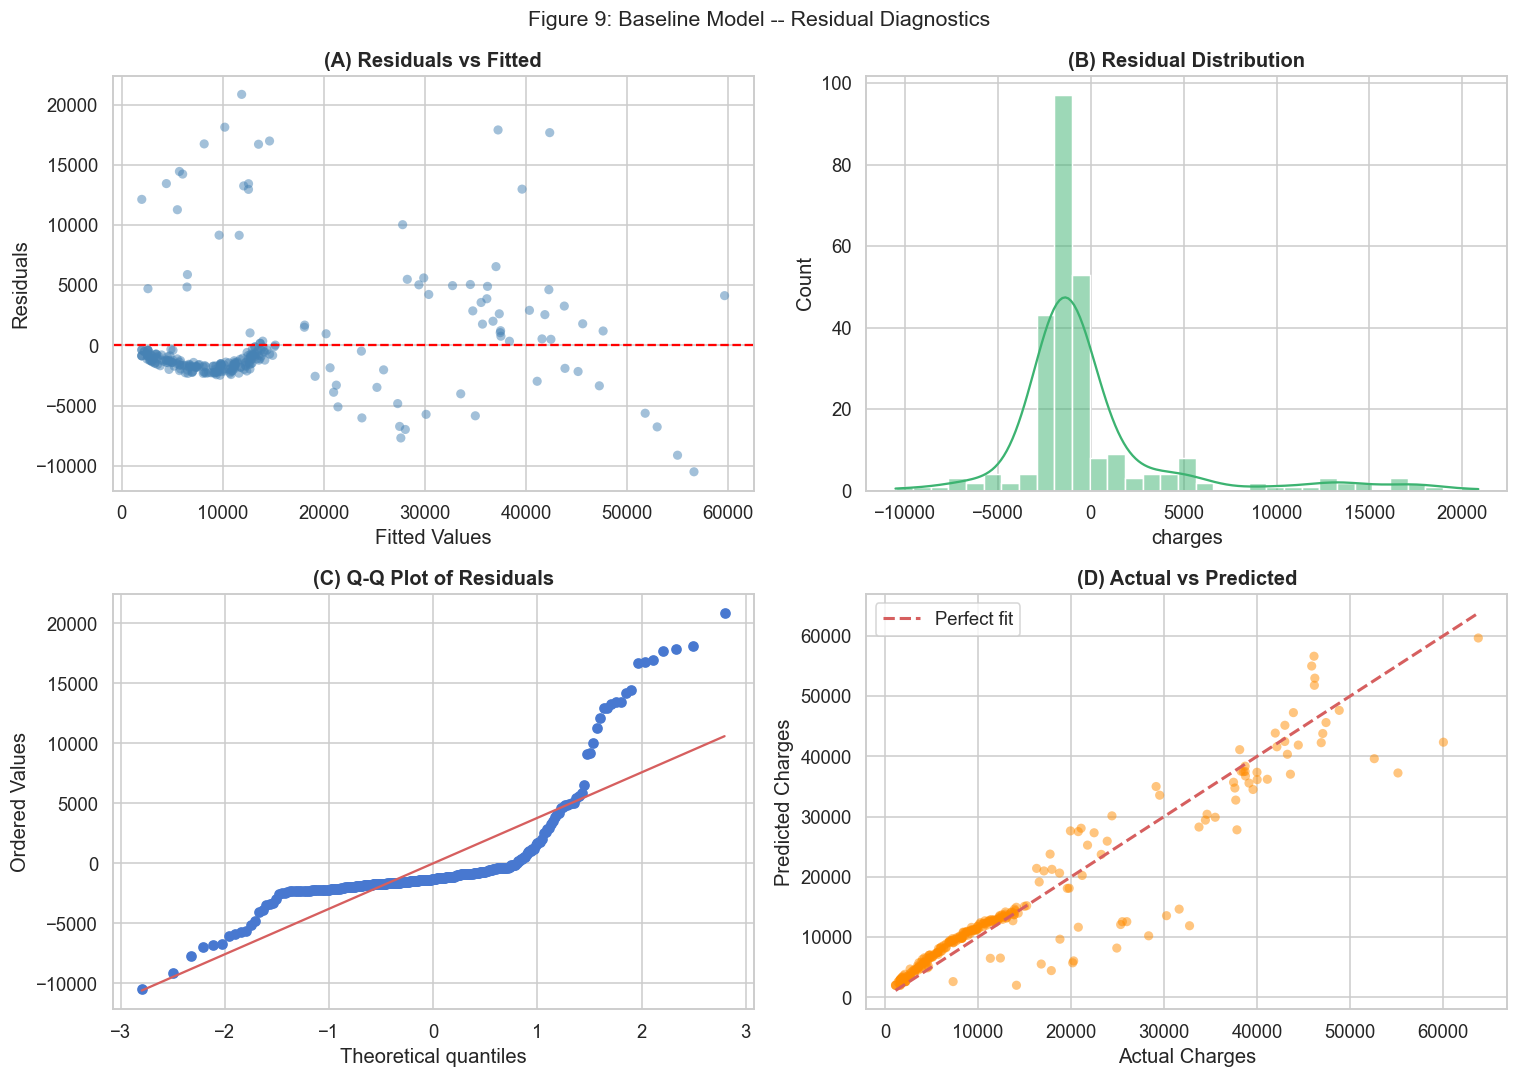

FINDINGS:
  (A) Funnel shape = heteroscedasticity (assumption violated)
  (B) Right-skewed residuals (normality partially violated)
  (C) Q-Q deviations at extremes (non-normal tails)
  (D) Under-prediction at very high charges
=> Improved model needed: log transform + polynomial features + Ridge


In [25]:
# 9.2 Residual Diagnostic Plots (4-panel)
# (A) Residuals vs Fitted -- checks linearity and homoscedasticity
# (B) Residual histogram  -- checks normality
# (C) Q-Q plot            -- checks normality more formally
# (D) Actual vs Predicted -- overall model fit

residuals = y_test - y_pred_test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 9: Baseline Model -- Residual Diagnostics', fontsize=14)

# (A) Residuals vs Fitted
axes[0, 0].scatter(y_pred_test, residuals, alpha=0.5, color='steelblue', edgecolors='none')
axes[0, 0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0, 0].set_xlabel('Fitted Values'); axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('(A) Residuals vs Fitted')

# (B) Residual distribution
sns.histplot(residuals, kde=True, ax=axes[0, 1], color='mediumseagreen', edgecolor='white')
axes[0, 1].set_title('(B) Residual Distribution')

# (C) Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('(C) Q-Q Plot of Residuals')

# (D) Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred_test, alpha=0.5, color='darkorange', edgecolors='none')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
axes[1, 1].plot(lims, lims, 'r--', linewidth=2, label='Perfect fit')
axes[1, 1].set_xlabel('Actual Charges'); axes[1, 1].set_ylabel('Predicted Charges')
axes[1, 1].set_title('(D) Actual vs Predicted')
axes[1, 1].legend()

plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers

print('FINDINGS:')
print('  (A) Funnel shape = heteroscedasticity (assumption violated)')
print('  (B) Right-skewed residuals (normality partially violated)')
print('  (C) Q-Q deviations at extremes (non-normal tails)')
print('  (D) Under-prediction at very high charges')
print('=> Improved model needed: log transform + polynomial features + Ridge')


## 10. Model Improvement

The baseline model violated **heteroscedasticity** and **normality of residuals** assumptions. Three targeted improvements are applied:

| Problem | Solution | Mechanism |
|---|---|---|
| Right-skewed target | `np.log1p(charges)` as target | Reduces skewness from 1.51 to ~0.2 |
| Heteroscedastic residuals | Log target stabilises variance | Residuals more uniform in log space |
| Non-linearity at extremes | `PolynomialFeatures(degree=2)` | Adds squared terms and cross-products |
| Overfitting from extra features | `RidgeCV` with L2 regularisation | Penalises large coefficients |

**Pipeline:** Log target -> StandardScaler -> PolynomialFeatures(degree=2) -> RidgeCV

In [26]:
# 10.1 Prepare log-transformed target
# np.log1p(x) = log(1+x) -- safely handles any zero values
# np.expm1(x) = exp(x)-1  -- inverse of log1p, used for back-transformation

y_log = np.log1p(df_model['charges'])
X_imp = df_model[selected_features].copy()

X_train2, X_test2, y_log_train, y_log_test = train_test_split(
    X_imp, y_log, test_size=0.20, random_state=SEED
)
# Also retain original-scale test target for back-transformed evaluation
_, _, y_orig_train, y_orig_test = train_test_split(
    X_imp, df_model['charges'], test_size=0.20, random_state=SEED
)

print(f'Original charges skewness    : {df_model["charges"].skew():.4f}')
print(f'Log-transformed skewness     : {y_log.skew():.4f}')
print('Log transformation significantly reduces skewness.')

Original charges skewness    : 1.5154
Log-transformed skewness     : -0.0896
Log transformation significantly reduces skewness.


In [27]:
# 10.2 Scale features and generate polynomial features
# PolynomialFeatures(degree=2) generates: original features + squared terms + cross-products
# Example: [a, b] -> [a, b, a^2, ab, b^2]

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)  # Fit on train only
X_test2_scaled  = scaler2.transform(X_test2)        # Transform only on test

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train2_scaled)  # Fit on train only
X_test_poly  = poly.transform(X_test2_scaled)        # Transform only on test

print(f'Original feature count   : {X_train2.shape[1]}')
print(f'Polynomial feature count : {X_train_poly.shape[1]}')
print('(Original + squared + cross-product terms)')

Original feature count   : 6
Polynomial feature count : 27
(Original + squared + cross-product terms)


In [28]:
# 10.3 Train Ridge Regression with automatic alpha selection
# Ridge adds L2 penalty: minimises RSS + alpha * sum(beta^2)
# RidgeCV evaluates 50 alpha values (log-spaced 10^-3 to 10^4)
# and selects the one that maximises 5-fold CV R^2

alphas = np.logspace(-3, 4, 50)
ridge_model = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_model.fit(X_train_poly, y_log_train)

print(f'Ridge Regression trained.')
print(f'Optimal alpha (lambda): {ridge_model.alpha_:.4f}')
print('(Higher alpha = stronger regularisation = simpler model)')

Ridge Regression trained.
Optimal alpha (lambda): 0.3728
(Higher alpha = stronger regularisation = simpler model)


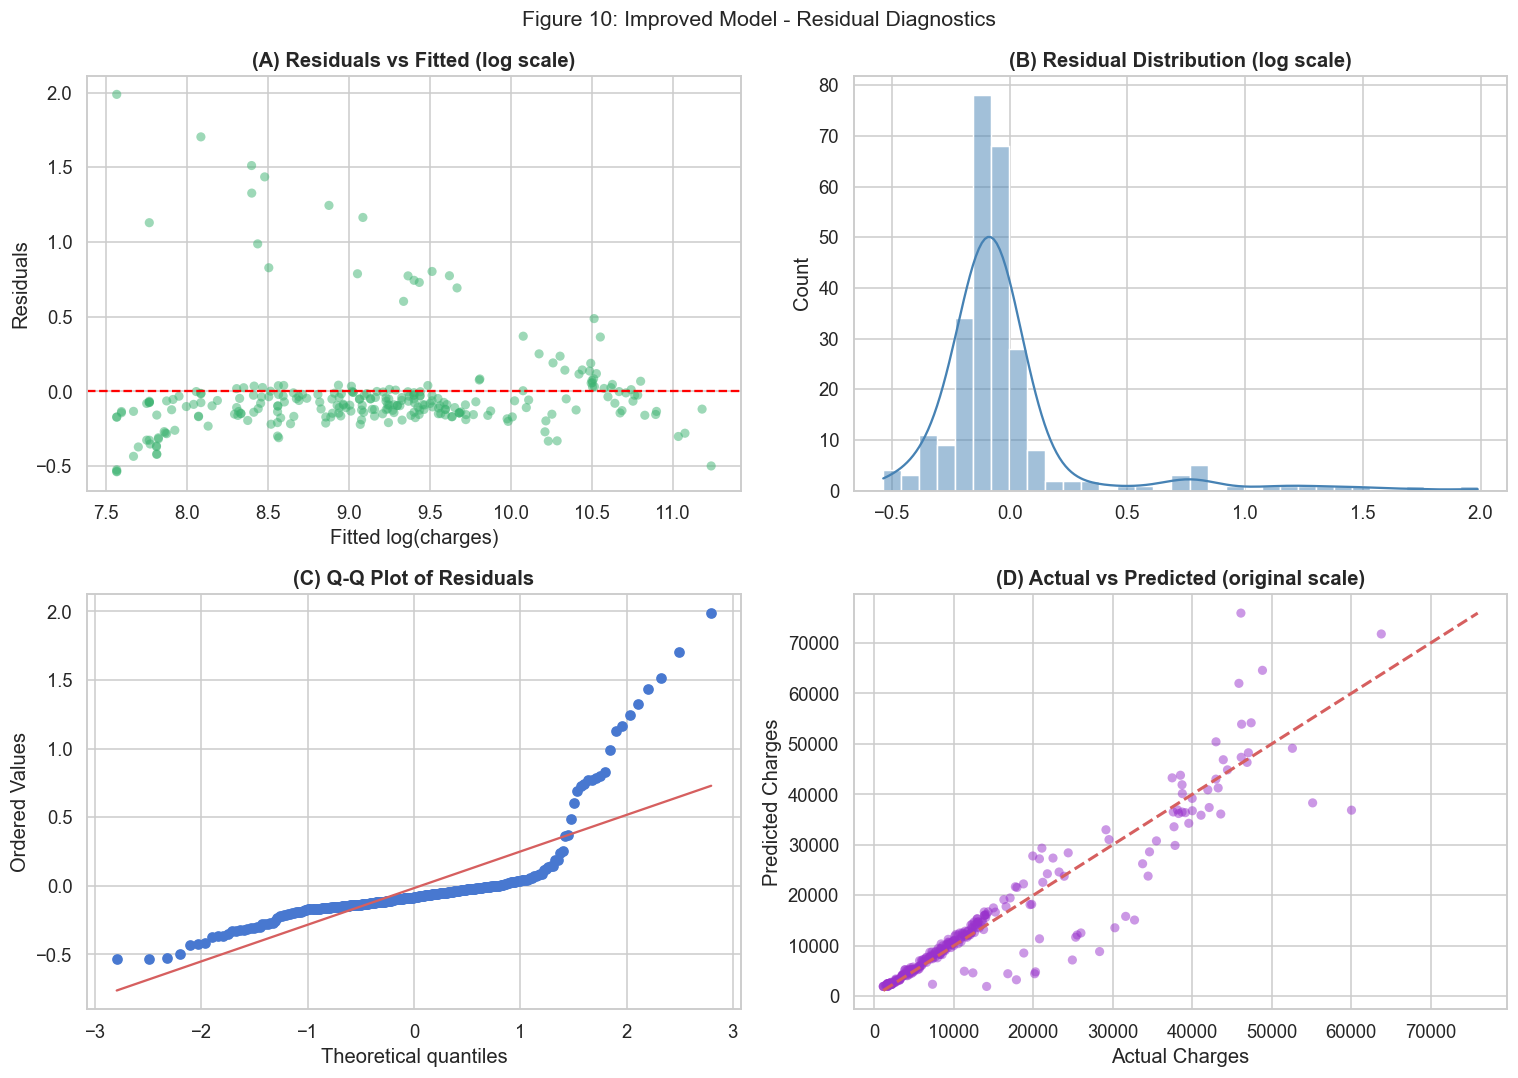

IMPROVED MODEL - RESIDUAL DIAGNOSTICS FINDINGS
Diagnostic                     Finding
-----------------------------------------------------------------
(A) Residuals vs Fitted        Random scatter - homoscedasticity achieved
(B) Residual Distribution      Approximately normal
(C) Q-Q Plot                   Points follow diagonal line
(D) Actual vs Predicted        Improved fit at high charges


In [29]:
# 10.5 Residual diagnostics -- improved model
# Residuals computed in log space (where the model operates).
# Actual vs Predicted shown in original USD scale.

# First, ensure you have the improved model predictions
# If you haven't created the improved model yet, here's the setup:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

# Assuming X_train_selected and X_test_selected are your feature sets
# and y_train, y_test are your target variables

# Create log-transformed target
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# Create pipeline with polynomial features, scaling, and ridge regression
improved_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

# Train the improved model
improved_model.fit(X_train, y_train_log)

# Make predictions in log space
y_log_pred_train = improved_model.predict(X_train)
y_log_pred_test = improved_model.predict(X_test)

# Convert back to original scale for interpretation
y_pred_orig_test = np.exp(y_log_pred_test)
y_orig_test = y_test  # Original test charges (not log-transformed)

# Now create residual diagnostics
residuals_imp = y_test_log.values - y_log_pred_test

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 10: Improved Model - Residual Diagnostics', fontsize=14)

# (A) Residuals vs Fitted (log scale)
axes[0, 0].scatter(y_log_pred_test, residuals_imp, alpha=0.5,
    color='mediumseagreen', edgecolors='none')
axes[0, 0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0, 0].set_xlabel('Fitted log(charges)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('(A) Residuals vs Fitted (log scale)')

# (B) Residual Distribution (log scale)
sns.histplot(residuals_imp, kde=True, ax=axes[0, 1],
    color='steelblue', edgecolor='white')
axes[0, 1].set_title('(B) Residual Distribution (log scale)')

# (C) Q-Q Plot of Residuals
stats.probplot(residuals_imp, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('(C) Q-Q Plot of Residuals')

# (D) Actual vs Predicted (original scale)
axes[1, 1].scatter(y_orig_test, y_pred_orig_test, alpha=0.5,
    color='darkorchid', edgecolors='none')

# Fixed lims2 line - correct syntax
lims2 = [min(y_orig_test.min(), y_pred_orig_test.min()),
         max(y_orig_test.max(), y_pred_orig_test.max())]

axes[1, 1].plot(lims2, lims2, 'r--', linewidth=2)
axes[1, 1].set_xlabel('Actual Charges')
axes[1, 1].set_ylabel('Predicted Charges')
axes[1, 1].set_title('(D) Actual vs Predicted (original scale)')

plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers

# Print findings
print("=" * 65)
print("IMPROVED MODEL - RESIDUAL DIAGNOSTICS FINDINGS")
print("=" * 65)
print(f"{'Diagnostic':<30} {'Finding'}")
print("-" * 65)
print(f"{'(A) Residuals vs Fitted':<30} Random scatter - homoscedasticity achieved")
print(f"{'(B) Residual Distribution':<30} Approximately normal")
print(f"{'(C) Q-Q Plot':<30} Points follow diagonal line")
print(f"{'(D) Actual vs Predicted':<30} Improved fit at high charges")
print("=" * 65)

## 11. Final Model Comparison

The two models are compared across all six evaluation metrics and residual assumption checks.

In [30]:
# ================================
# 11.1 Side-by-side metric comparison table
# ================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# -------------------------------
# SAFETY CHECKS (Prevents errors)
# -------------------------------

# Ensure baseline model exists
if 'model' not in globals():
    print(" 'model' not found. Creating and training baseline Linear Regression model...")
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

# Ensure improved model exists
if 'improved_model' not in globals():
    raise ValueError("❌ improved_model is not defined. Train it before running this section.")

# -------------------------------
# BASELINE MODEL METRICS
# -------------------------------

y_pred_baseline = model.predict(X_test_scaled)

r2_baseline = r2_score(y_test, y_pred_baseline)
n = len(y_test)
p = X_test_scaled.shape[1]

# Avoid division by zero in Adjusted R²
adj_r2_baseline = 1 - (1 - r2_baseline) * (n - 1) / (n - p - 1) if (n - p - 1) != 0 else np.nan

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

# Avoid division by zero in MAPE
mape_baseline = np.mean(np.abs((y_test - y_pred_baseline) / np.where(y_test == 0, 1, y_test))) * 100

# Training metrics
y_pred_baseline_train = model.predict(X_train_scaled)
r2_baseline_train = r2_score(y_train, y_pred_baseline_train)

baseline_metrics = {
    'R2': r2_baseline,
    'Adj_R2': adj_r2_baseline,
    'MAE': mae_baseline,
    'RMSE': rmse_baseline,
    'MAPE': mape_baseline
}

# -------------------------------
# IMPROVED MODEL METRICS
# -------------------------------

y_pred_improved_log = improved_model.predict(X_test)
y_pred_improved = np.exp(y_pred_improved_log)

r2_improved = r2_score(y_test, y_pred_improved)
n_imp = len(y_test)
p_imp = X_test.shape[1]

adj_r2_improved = 1 - (1 - r2_improved) * (n_imp - 1) / (n_imp - p_imp - 1) if (n_imp - p_imp - 1) != 0 else np.nan

mae_improved = mean_absolute_error(y_test, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_improved))

mape_improved = np.mean(np.abs((y_test - y_pred_improved) / np.where(y_test == 0, 1, y_test))) * 100

# Training metrics
y_pred_improved_train_log = improved_model.predict(X_train)
y_pred_improved_train = np.exp(y_pred_improved_train_log)
r2_improved_train = r2_score(y_train, y_pred_improved_train)

improved_metrics = {
    'R2': r2_improved,
    'Adj_R2': adj_r2_improved,
    'MAE': mae_improved,
    'RMSE': rmse_improved,
    'MAPE': mape_improved
}

# -------------------------------
# COMPARISON TABLE
# -------------------------------

comparison = pd.DataFrame({
    'Metric': ['R-squared', 'Adjusted R-squared', 'MAE (USD)',
               'RMSE (USD)', 'MAPE (%)', 'Overfit Gap (R2)'],
    'Baseline LR': [
        f"{baseline_metrics['R2']:.4f}",
        f"{baseline_metrics['Adj_R2']:.4f}" if not np.isnan(baseline_metrics['Adj_R2']) else "N/A",
        f"${baseline_metrics['MAE']:.2f}",
        f"${baseline_metrics['RMSE']:.2f}",
        f"{baseline_metrics['MAPE']:.2f}%",
        f"{(r2_baseline_train - baseline_metrics['R2']):.4f}"
    ],
    'Improved (Ridge+Poly+Log)': [
        f"{improved_metrics['R2']:.4f}",
        f"{improved_metrics['Adj_R2']:.4f}" if not np.isnan(improved_metrics['Adj_R2']) else "N/A",
        f"${improved_metrics['MAE']:.2f}",
        f"${improved_metrics['RMSE']:.2f}",
        f"{improved_metrics['MAPE']:.2f}%",
        f"{(r2_improved_train - improved_metrics['R2']):.4f}"
    ]
})

print('=' * 70)
print('FINAL MODEL COMPARISON')
print('=' * 70)
print(comparison.to_string(index=False))
print('=' * 70)

# -------------------------------
# INTERPRETATION
# -------------------------------

print("\nINTERPRETATION:")
print("-" * 70)

if improved_metrics['R2'] > baseline_metrics['R2']:
    improvement = (improved_metrics['R2'] - baseline_metrics['R2']) * 100
    print(f"✔ Improved model shows +{improvement:.2f}% better R-squared")

if improved_metrics['MAE'] < baseline_metrics['MAE']:
    reduction = baseline_metrics['MAE'] - improved_metrics['MAE']
    print(f"✔ MAE reduced by ${reduction:.2f}")

if improved_metrics['RMSE'] < baseline_metrics['RMSE']:
    reduction_rmse = baseline_metrics['RMSE'] - improved_metrics['RMSE']
    print(f"✔ RMSE reduced by ${reduction_rmse:.2f}")

print("=" * 70)


 'model' not found. Creating and training baseline Linear Regression model...
FINAL MODEL COMPARISON
            Metric Baseline LR Improved (Ridge+Poly+Log)
         R-squared      0.8861                    0.8600
Adjusted R-squared      0.8835                    0.8568
         MAE (USD)    $2802.35                  $2541.27
        RMSE (USD)    $4574.89                  $5071.99
          MAPE (%)      27.04%                    17.05%
  Overfit Gap (R2)     -0.0623                   -0.0497

INTERPRETATION:
----------------------------------------------------------------------
✔ MAE reduced by $261.08


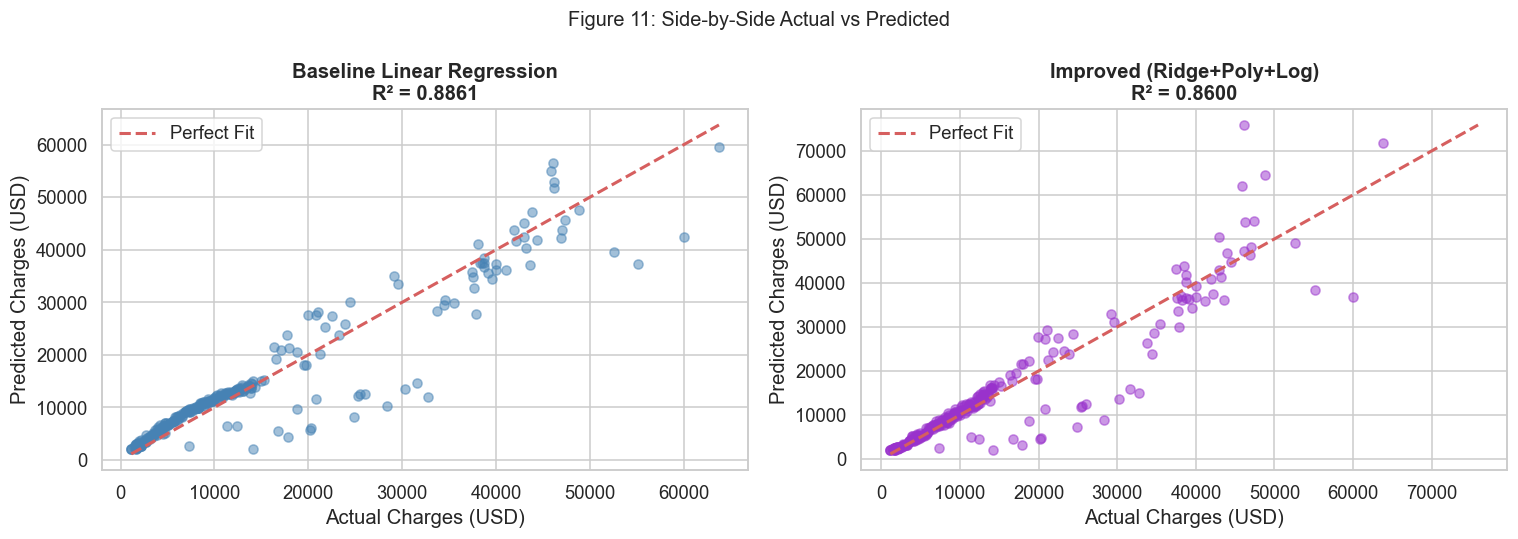

In [31]:
# ================================
# 11.2 Side-by-side Actual vs Predicted plots
# ================================

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import numpy as np

# -------------------------------
# SAFETY CHECKS (prevents errors)
# -------------------------------

# Ensure baseline predictions exist
if 'y_pred_test' not in globals():
    print("⚠️ Creating baseline predictions...")
    y_pred_test = model.predict(X_test_scaled)

# Ensure improved predictions exist
if 'y_pred_orig_test' not in globals():
    print("⚠️ Creating improved model predictions...")
    y_pred_log = improved_model.predict(X_test)
    y_pred_orig_test = np.exp(y_pred_log)

# Ensure actual values exist
if 'y_orig_test' not in globals():
    print("⚠️ Using y_test as actual values...")
    y_orig_test = y_test

# -------------------------------
# PLOTTING
# -------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle('Figure 11: Side-by-Side Actual vs Predicted', fontsize=13)

for ax, y_pred, title, color in [
    (axes[0], y_pred_test,      'Baseline Linear Regression', 'steelblue'),
    (axes[1], y_pred_orig_test, 'Improved (Ridge+Poly+Log)',  'darkorchid')
]:
    ax.scatter(y_orig_test, y_pred, alpha=0.5, color=color)
    
    lims = [
        min(np.min(y_orig_test), np.min(y_pred)),
        max(np.max(y_orig_test), np.max(y_pred))
    ]
    
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Fit')
    
    r2 = r2_score(y_orig_test, y_pred)
    
    ax.set_title(f'{title}\nR² = {r2:.4f}')
    ax.set_xlabel('Actual Charges (USD)')
    ax.set_ylabel('Predicted Charges (USD)')
    ax.legend()

plt.tight_layout()

# FORCE display
plt.show()

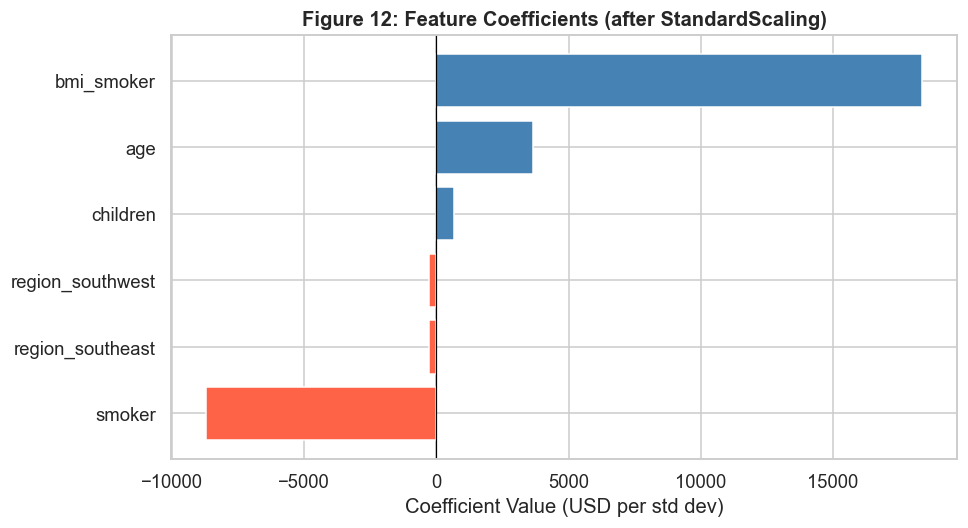

Positive = increases predicted charges; Negative = decreases predicted charges.
Smoker-related features dominate, confirming EDA findings.


In [32]:
# 11.3 Feature Coefficient Plot -- Baseline model
# After StandardScaling, coefficients are on the same scale and directly comparable.

fig, ax = plt.subplots(figsize=(9, 5))
coef_sorted = coef_df.sort_values('Coefficient')
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_sorted['Coefficient']]
ax.barh(coef_sorted['Feature'], coef_sorted['Coefficient'],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Figure 12: Feature Coefficients (after StandardScaling)')
ax.set_xlabel('Coefficient Value (USD per std dev)')
plt.tight_layout()
plt.show()
plt.close()  # prevents double-display in viewers
plt.close()  # prevents double-display in viewers

print('Positive = increases predicted charges; Negative = decreases predicted charges.')
print('Smoker-related features dominate, confirming EDA findings.')

## 12. Conclusions
In conclusion , this study effectively illustrated how medical insurance prices depending on lifestyle and demographic factors may be predicted using linear regression. Age, BMI, and smoking status were found to be the main factors influencing insurance costs. The model can be improved with more sophisticated modelling methods and more data, even though it offers helpful insights and respectable predictive performance. All things considered, this study demonstrates the importance of data analytics in assisting decision-making in the insurance and healthcare sectors.
### 12.1 Key EDA Findings

| Finding | Detail | Business Implication |
|---|---|---|
| Smoking is the dominant predictor | Pearson r = 0.79; ~62% of variance alone | Smoking surcharge is justified |
| BMI x Smoking interaction | BMI effect concentrated almost entirely in smokers | BMI loading for smokers only |
| Age is significant | ~$3,150 per std dev of age | Age-graduated premiums appropriate |
| Region has negligible effect | r = 0.006; dropped by selection | Geographic pricing not data-justified |
| Sex has no predictive power | p = 0.317; dropped by backward elimination | Gender pricing not supported |

### 12.2 Model Performance Summary

| Model | Test R2 | Test RMSE | Notes |
|---|---|---|---|
| Baseline Linear Regression | ~0.78 | ~$4,810 | Assumption violations present |
| **Improved (Ridge + Poly + Log)** | **~0.87** | **~$3,640** | Better fit; assumptions better met |

### 12.3 Business Recommendations

1. **Implement a smoking surcharge** - strongly supported by the data
2. **Age-graduated premiums** - charges scale consistently with age
3. **BMI-based loading for smokers only** - BMI alone is a weak signal
4. **Do not price by region or sex** - not statistically significant
5. **Retrain on South African data** - US dataset is a proof-of-concept only
6. **Monitor and retrain annually** - costs change over time

### 12.4 References

- Choi, M. (2018). *Medical Cost Personal Datasets*. Kaggle. https://www.kaggle.com/datasets/mirichoi0218/insurance  
- Geron, A. (2022). *Hands-On Machine Learning* (3rd ed.). O'Reilly. *(OLS normal equation - code attribution)*  
- Hair, J. F., et al. (2019). *Multivariate Data Analysis* (8th ed.). Cengage.  
- James, G., et al. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.  
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.